In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import streamlit as st 

df = pd.read_csv("UAC.csv")
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,21-Dec-25,6,18,11,"2,484",14
1,18-Dec-25,11,50,6,"2,472",16
2,17-Dec-25,7,31,11,"2,481",10
3,16-Dec-25,8,54,15,"2,468",9
4,15-Dec-25,11,42,9,"2,470",7


In [6]:
df.shape

(720, 6)

In [7]:
df.isnull().sum()

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

In [8]:
df.describe()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children discharged from HHS Care
count,720.000000,720.000000,720.000000,720.000000
mean,93.523611,171.494444,128.668056,173.406944
std,72.646625,126.354965,97.322012,125.702841
min,0.000000,7.000000,0.000000,0.000000
25%,12.000000,36.000000,14.000000,19.750000
50%,99.000000,193.000000,157.000000,181.000000
75%,147.250000,263.250000,199.250000,267.000000
max,333.000000,531.000000,440.000000,505.000000


In [9]:
df.columns.tolist()


['Date',
 'Children apprehended and placed in CBP custody*',
 'Children in CBP custody',
 'Children transferred out of CBP custody',
 'Children in HHS Care',
 'Children discharged from HHS Care']

In [10]:
df.columns =["Date","CBP_Apprehended","CBP_Custody",
             "CBP_Transferred","HHS_Care","HHS_Discharged"]
df = df.dropna(subset=["Date"])
df = df[df["Date"].str.strip() !=""]
df["Date"]=pd.to_datetime(df["Date"])
for col in["CBP_Apprehended","CBP_Transferred","HHS_Discharged"]:
    df[col]=df[col].astype(str).str.replace(",","").str.strip()
    df[col]=pd.to_numeric(df[col], errors="coerce")
df = df.dropna()
print("Done!", df.shape)

Done! (720, 6)


C:\Users\y8334\AppData\Local\Temp\ipykernel_16912\1850859532.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Date"]=pd.to_datetime(df["Date"])


In [11]:
df.describe()

,Date,CBP_Apprehended,CBP_Custody,CBP_Transferred,HHS_Discharged
count,720,720.000000,720.000000,720.000000,720.000000
mean,2024-07-06 05:30:00,93.523611,171.494444,128.668056,173.406944
min,2023-01-12 00:00:00,0.000000,7.000000,0.000000,0.000000
25%,2023-10-16 18:00:00,12.000000,36.000000,14.000000,19.750000
50%,2024-07-05 12:00:00,99.000000,193.000000,157.000000,181.000000
75%,2025-03-25 06:00:00,147.250000,263.250000,199.250000,267.000000
max,2025-12-21 00:00:00,333.000000,531.000000,440.000000,505.000000
std,NaN,72.646625,126.354965,97.322012,125.702841


In [12]:
df.isnull().sum()

Date               0
CBP_Apprehended    0
CBP_Custody        0
CBP_Transferred    0
HHS_Care           0
HHS_Discharged     0
dtype: int64

In [13]:
df.columns.tolist()

['Date',
 'CBP_Apprehended',
 'CBP_Custody',
 'CBP_Transferred',
 'HHS_Care',
 'HHS_Discharged']

In [14]:
df["Date"] = pd.to_datetime(df["Date"], format="mixed")
df = df.sort_values("Date").reset_index(drop=True)
print(df["Date"].head())
print(df.shape)

0   2023-01-12
1   2023-01-22
2   2023-01-23
3   2023-01-24
4   2023-01-25
Name: Date, dtype: datetime64[us]
(720, 6)


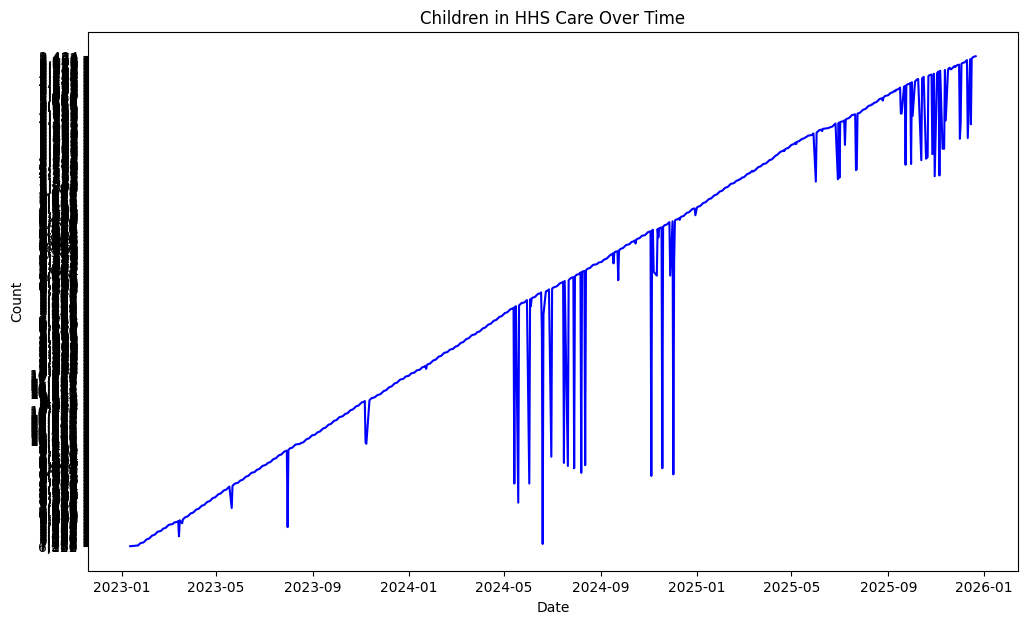

In [17]:
plt.figure(figsize=(12,7))
plt.plot(df["Date"], df["HHS_Care"], color="blue", linewidth=1.5)
plt.title("Children in HHS Care Over Time")
plt.xlabel("Date")
plt.ylabel("Count")
plt.show()